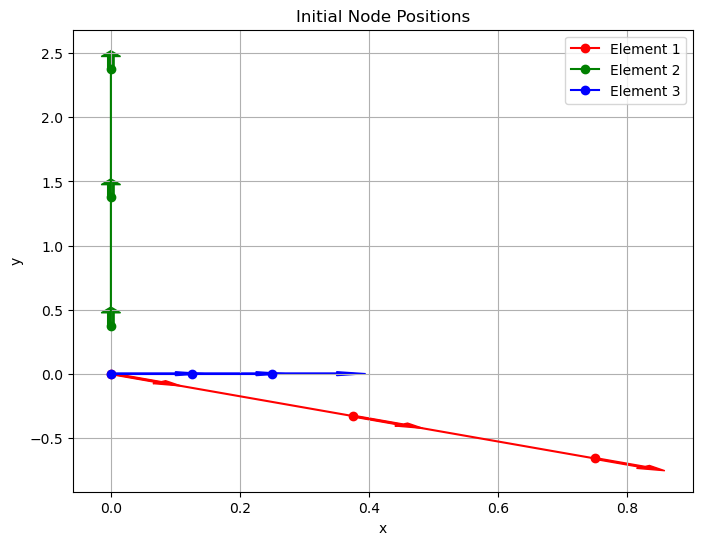

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Number of nodes per element in each dimension
NoN = np.array([3, 3, 3])

# Total number of nodes
TotalNoN = np.sum(NoN)

# Lengths of the structure in each dimension
L = np.array([1, 2, 0.25])

# Initialize q0
q0 = np.zeros((TotalNoN * 3, 1))

# Locations of rotational joints A and D
LocA = np.array([0, 0])
LocD = np.array([0.5, 0.5])

# Calculate theta values for each element
theta = np.array([-0.72273, 1.57080, 0.00000])

# Calculate x, y, and theta values for each node
idx = 0
for dim in range(3):
    # Calculate the spacing between nodes in this dimension
    delta = L[dim] / (NoN[dim] - 1)
    
    # Starting position for the current element
    if dim == 0:
        start_pos = LocA
    else:
        start_pos = q0[(dim - 1) * NoN[dim - 1] * 3 : dim * NoN[dim - 1] * 3 - 1 : 3]
    
    # Fill q0 with x, y, and theta values for each node
    for node in range(NoN[dim]):
        q0[idx] = start_pos[0] + node * delta * np.cos(theta[dim])  # x coordinate
        q0[idx + 1] = start_pos[1] + node * delta * np.sin(theta[dim])  # y coordinate
        q0[idx + 2] = theta[dim]  # theta (angle)
        idx += 3  # Increment index for the next set of coordinates

# Reshape q0 into a 2D array for plotting
q0_plot = np.reshape(q0, (-1, 3))

# Plot the nodes with different colors for each element
plt.figure(figsize=(8, 6))
colors = ['r', 'g', 'b']  # Define colors for each element
for dim in range(3):
    start_idx = dim * NoN[dim]
    end_idx = (dim + 1) * NoN[dim]
    plt.plot(q0_plot[start_idx:end_idx, 0], q0_plot[start_idx:end_idx, 1], 'o-', color=colors[dim], label=f'Element {dim+1}')
    for i in range(NoN[dim]):
        x, y, theta = q0_plot[start_idx+i]
        dx = 0.1 * np.cos(theta)
        dy = 0.1 * np.sin(theta)
        plt.arrow(x, y, dx, dy, color=colors[dim], width=0.01)

plt.xlabel('x')
plt.ylabel('y')
plt.title('Initial Node Positions')
plt.grid(True)
plt.legend()
plt.show()


In [7]:
for node in range(NoN[dim]):
    print(node)

0
1
2
